# Washington Collection Transposon Mutant Analysis

## Overview
This notebook analyzes batch tolerance of P. aeruginosa transposon mutants from the Washington collection and generates Figures S7A and S7B.

## Analysis Workflow
1. **Load Data**: Import CFU survival data from Excel file
2. **Generate Figure S7A**: Absolute survival values for all strains
3. **Generate Figure S7B**: Fold change relative to Δ5183 reference strain
4. **Statistical Analysis**: One-sample t-test comparing each mutant to reference

## Experimental Design
- **Donor strains**: SVS002, Δ5183, and 8 transposon mutants
- **Timepoint**: 8 hours post-treatment
- **Reference strain**: Δ5183 (used for fold-change normalization)
- **Transposon mutants**: toxA, rhlA, pqsL, mucA, lasI, lasB, lasA, dspI

## Outputs
- `S7A_batch_tolerance_Tn_mutants.pdf`: Absolute survival values
- `S7B_batch_tolerance_Tn_mutants_FC.pdf`: Fold change relative to Δ5183

In [2]:
# Data analysis and visualization packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# File handling
import os

# Set publication-quality style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['ytick.major.size'] = 3
plt.rcParams['pdf.fonttype'] = 42  # Editable text in PDF
plt.rcParams['ps.fonttype'] = 42


# Step 1: Load and Inspect Data

## Objective
Load CFU survival data from Excel file and verify data structure.

## Data Structure
Expected columns:
- `Donor`: Strain name
- `Timepoint`: Time post-treatment
- `Survival`: CFU count (log scale)
- `Replicate` (optional): Biological replicate identifier

In [4]:
# Load data
df = pd.read_csv('2024-02-15-cfu.csv')

# Display data
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {', '.join(df.columns)}")
print(f"\nUnique donors: {', '.join(df['Donor'].unique())}")
print(f"Timepoints: {', '.join(df['Timepoint'].unique())}")

df

Dataset shape: 240 rows × 10 columns

Columns: Target, Donor, Supernatant, Antibiotics, Timepoint, Replicates, Colonies, Dilution, CFU, Survival

Unique donors: SVS002, Tn dspI, Tn lasA, Tn lasB, Tn lasI, Tn mucA, Tn pqsL, Tn rhlA, Tn toxA, ∆5183, ∆5183 pQFT pqsL, ∆5183 pQFT rhlAB, ∆pqsL, ∆pqsL pQFT pqsL, ∆rhlA, ∆rhlA pQFT rhlAB
Timepoints: 0h, 1h, 4h, 8h, 24h


,Target,Donor,Supernatant,Antibiotics,Timepoint,Replicates,Colonies,Dilution,CFU,Survival
0,SVS002,SVS002,1mM cumate,Tobramycin (58µg/ml),0h,1,54,0.00001,1.080000e+09,1.000000e+00
1,SVS002,SVS002,1mM cumate,Tobramycin (58µg/ml),0h,2,43,0.00001,8.600000e+08,1.000000e+00
2,SVS002,SVS002,1mM cumate,Tobramycin (58µg/ml),0h,3,41,0.00001,8.200000e+08,1.000000e+00
3,SVS002,SVS002,1mM cumate,Tobramycin (58µg/ml),1h,1,4,0.10000,8.000000e+03,7.407407e-06
4,SVS002,SVS002,1mM cumate,Tobramycin (58µg/ml),1h,2,9,0.10000,1.800000e+04,2.093023e-05
...,...,...,...,...,...,...,...,...,...,...
235,SVS002,∆rhlA pQFT rhlAB,1mM cumate,Tobramycin (58µg/ml),8h,2,16,0.00010,3.200000e+07,2.962963e-02
236,SVS002,∆rhlA pQFT rhlAB,1mM cumate,Tobramycin (58µg/ml),8h,3,15,0.00010,3.000000e+07,3.488372e-02
237,SVS002,∆rhlA pQFT rhlAB,1mM cumate,Tobramycin (58µg/ml),24h,1,1,1.00000,2.000000e+02,2.702703e-07
238,SVS002,∆rhlA pQFT rhlAB,1mM cumate,Tobramycin (58µg/ml),24h,2,1,1.00000,2.000000e+02,1.851852e-07


# Step 2: Generate Figure S7A - Absolute Survival Values

## Objective
Create bar plot showing absolute survival (log CFU) for all strains at 8-hour timepoint.

## Visualization Details
- **Group 1** (control strains): SVS002, Δ5183 - shown in yellow and blue
- **Group 2** (Tn mutants): 8 transposon mutants - shown in brown tones
- Individual data points overlaid on bars
- Horizontal dashed line indicates Δ5183 mean
- Groups separated by vertical line

✅ Figure saved: S7A_batch_tolerance_Tn_mutants.pdf


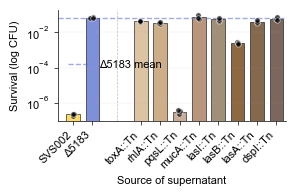

In [5]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Define strain groups
group1 = ['SVS002', '∆5183']  # Control strains
group2 = ['Tn toxA', 'Tn rhlA', 'Tn pqsL', 'Tn mucA', 
          'Tn lasI', 'Tn lasB', 'Tn lasA', 'Tn dspI']  # Transposon mutants

# Define colors
colors_g1 = ['#ffd332', '#5f74d1']  # Yellow, blue
colors_g2 = ['#D2B48C', '#C19A6B', '#BC987E', '#A67B5B', 
             '#8B7355', '#704214', '#654321', '#5C4033']  # Brown tones

# Analysis parameters
timepoint = '8h'
bar_width = 0.7
gap = 1.5  # Gap between groups

# Output file
output_file = 'S7A_batch_tolerance_Tn_mutants.pdf'

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, ax = plt.subplots(figsize=(3, 2))

# Calculate bar positions
pos_g1 = np.arange(len(group1))
pos_g2 = np.arange(len(group2)) + len(group1) + gap

all_positions = np.concatenate([pos_g1, pos_g2])
all_strains = group1 + group2
all_colors = colors_g1 + colors_g2

# Get Δ5183 mean value for reference line
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]
delta_5183_mean = df_5183['Survival'].mean() if len(df_5183) > 0 else None

# Plot bars and data points
for pos, donor, color in zip(all_positions, all_strains, all_colors):
    # Filter data for this strain and timepoint
    df_subset = df[(df['Donor'] == donor) & (df['Timepoint'] == timepoint)]
    
    if len(df_subset) > 0:
        # Calculate mean
        mean_val = df_subset['Survival'].mean()
        
        # Plot bar
        ax.bar(pos, mean_val, bar_width,
               color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Overlay individual data points with jitter
        y_values = df_subset['Survival'].values
        x_jitter = np.random.normal(pos, 0.05, len(y_values))
        ax.scatter(x_jitter, y_values, 
                   color='black', s=15, alpha=0.7, zorder=3, 
                   edgecolors='white', linewidths=0.5)

# Add horizontal reference line at Δ5183 level
if delta_5183_mean is not None:
    ax.axhline(delta_5183_mean, color='#5f74d1', linestyle='--', 
               linewidth=1, alpha=0.6, zorder=1, label='Δ5183 mean')

# Add vertical separator between groups
group_sep = (pos_g1[-1] + pos_g2[0]) / 2
ax.axvline(group_sep, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# =============================================================================
# FORMATTING
# =============================================================================

# Axis labels
ax.set_ylabel('Survival (log CFU)', fontsize=8)
ax.set_xlabel('Source of supernatant', fontsize=8)
ax.set_yscale('log')

# X-axis tick labels (convert 'Tn toxA' to 'toxA::Tn')
ax.set_xticks(all_positions)
labels = []
for s in all_strains:
    s = s.replace('∆', 'Δ')
    if s.startswith('Tn '):
        gene = s.replace('Tn ', '')
        s = f'{gene}::Tn'
    labels.append(s)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)

# Axis limits
ax.set_xlim(-0.8, all_positions[-1] + 0.5)

# Apply publication style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.25, axis='y')
ax.tick_params(axis='both', labelsize=8)

# Add legend
ax.legend(frameon=False, fontsize=8, loc='best')

plt.tight_layout()

# Save figure
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_file}")
plt.show()

# Step 3: Generate Figure S7B - Fold Change Relative to Δ5183

## Objective
Create bar plot showing fold change in survival relative to Δ5183 reference strain.

## Method
- Calculate geometric mean fold change for each mutant
- Show individual replicate fold changes as scatter points
- Annotate bars with fold change values
- Horizontal line at FC = 1 indicates Δ5183 level

## Fold Change Calculation
$$\text{Fold Change} = 2^{\text{mean}(\log_2(\text{Survival}_{\text{mutant}} / \text{Survival}_{\Delta5183}))}$$

✅ Figure saved: S7B_batch_tolerance_Tn_mutants_FC.pdf


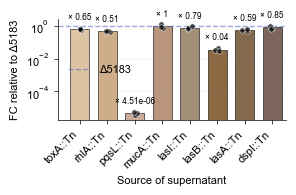

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Only Tn mutants (excluding control strains)
group2 = ['Tn toxA', 'Tn rhlA', 'Tn pqsL', 'Tn mucA', 
          'Tn lasI', 'Tn lasB', 'Tn lasA', 'Tn dspI']

# Colors: brown tones
colors_g2 = ['#D2B48C', '#C19A6B', '#BC987E', '#A67B5B', 
             '#8B7355', '#704214', '#654321', '#5C4033']

# Analysis parameters
timepoint = '8h'
bar_width = 0.7

# Output file
output_file = 'S7B_batch_tolerance_Tn_mutants_FC.pdf'

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, ax = plt.subplots(figsize=(3, 2))

# Calculate positions
pos_g2 = np.arange(len(group2))
all_positions = pos_g2
all_strains = group2
all_colors = colors_g2

# Get Δ5183 mean value as reference
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]
if len(df_5183) > 0:
    delta_5183_mean = df_5183['Survival'].mean()
else:
    delta_5183_mean = None
    print("⚠️ Warning: No data for Δ5183")

# Plot bars with fold change
for pos, donor, color in zip(all_positions, all_strains, all_colors):
    df_subset = df[(df['Donor'] == donor) & (df['Timepoint'] == timepoint)]
    
    if len(df_subset) > 0 and delta_5183_mean is not None:
        # Calculate geometric mean of fold change
        individual_fcs = df_subset['Survival'].values / delta_5183_mean
        log2_fcs = np.log2(individual_fcs)
        mean_log2_fc = np.mean(log2_fcs)
        fold_change = 2**mean_log2_fc  # Geometric mean
        
        # Plot bar
        ax.bar(pos, fold_change, bar_width,
               color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Overlay individual replicate fold changes
        x_jitter = np.random.normal(pos, 0.05, len(individual_fcs))
        ax.scatter(x_jitter, individual_fcs, 
                   color='black', s=15, alpha=0.7, zorder=3, 
                   edgecolors='white', linewidths=0.5)
        
        # Add fold change annotation
        if fold_change >= 1:
            label_text = f'× {fold_change:.0f}'
        elif fold_change >= 0.01:
            label_text = f'× {fold_change:.2f}'
        else:
            label_text = f'× {fold_change:.2e}'
        
        # Position text above bar
        y_text = fold_change * 3
        ax.text(pos, y_text, label_text, 
                ha='center', va='bottom', fontsize=6, fontweight='normal')

# Add horizontal reference line at FC = 1 (Δ5183 level)
ax.axhline(1, color='#5f74d1', linestyle='--', 
           linewidth=1, alpha=0.6, zorder=1, label='Δ5183')

# =============================================================================
# FORMATTING
# =============================================================================

# Axis labels
ax.set_ylabel('FC relative to Δ5183', fontsize=8)
ax.set_xlabel('Source of supernatant', fontsize=8)
ax.set_yscale('log')

# X-axis tick labels (convert 'Tn toxA' to 'toxA::Tn')
ax.set_xticks(all_positions)
labels = []
for s in all_strains:
    if s.startswith('Tn '):
        gene = s.replace('Tn ', '')
        s = f'{gene}::Tn'
    labels.append(s)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)

# Axis limits
ax.set_xlim(-0.8, all_positions[-1] + 0.5)

# Apply publication style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.25, axis='y')
ax.tick_params(axis='both', labelsize=8)

# Add legend
ax.legend(fontsize=8, frameon=False, loc='best')

plt.tight_layout()

# Save figure
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_file}")
plt.show()

# Step 4: Statistical Analysis

## Objective
Perform statistical comparison of each transposon mutant against Δ5183 reference strain.

## Method
- **Test**: One-sample t-test on log₂(Fold Change)
- **Null hypothesis**: Mean log₂FC = 0 (i.e., FC = 1, no difference from Δ5183)
- **Alternative hypothesis**: Mean log₂FC ≠ 0 (i.e., FC ≠ 1, different from Δ5183)
- **Multiple testing correction**: Bonferroni correction

## Interpretation
- `***` p < 0.001 (highly significant difference)
- `**` p < 0.01 (significant difference)
- `*` p < 0.05 (significant difference)
- `ns` p ≥ 0.05 (not significant)
- Mean_FC > 1: Higher survival than Δ5183
- Mean_FC < 1: Lower survival than Δ5183

In [7]:
# =============================================================================
# CALCULATE FOLD CHANGES FOR EACH BIOLOGICAL REPLICATE
# =============================================================================

timepoint = '8h'
group2 = ['Tn toxA', 'Tn rhlA', 'Tn pqsL', 'Tn mucA', 
          'Tn lasI', 'Tn lasB', 'Tn lasA', 'Tn dspI']

# Get reference (Δ5183) values
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]

# Calculate fold changes for each biological replicate
fold_change_data = []

for strain in group2:
    df_strain = df[(df['Donor'] == strain) & (df['Timepoint'] == timepoint)]
    
    # For each biological replicate, calculate fold change
    for idx, row in df_strain.iterrows():
        # Get corresponding Δ5183 value (paired if available, otherwise mean)
        if 'Replicate' in df.columns and row['Replicate'] in df_5183['Replicate'].values:
            # Paired design: use same replicate
            ref_value = df_5183[df_5183['Replicate'] == row['Replicate']]['Survival'].values[0]
        else:
            # Unpaired: use mean of reference
            ref_value = df_5183['Survival'].mean()
        
        fc = row['Survival'] / ref_value
        log2_fc = np.log2(fc) if fc > 0 else np.nan
        
        fold_change_data.append({
            'Strain': strain,
            'Survival': row['Survival'],
            'FoldChange': fc,
            'Log2FC': log2_fc,
            'Replicate': row.get('Replicate', idx)
        })

df_fc = pd.DataFrame(fold_change_data)
df_fc = df_fc.dropna(subset=['Log2FC'])  # Remove any NaN values

# =============================================================================
# STATISTICAL TESTING
# =============================================================================

results = []

for strain in group2:
    log2fc_values = df_fc[df_fc['Strain'] == strain]['Log2FC'].values
    
    if len(log2fc_values) >= 3:  # Need at least 3 replicates
        # One-sample t-test: test if log2FC is significantly different from 0
        t_stat, p_value = stats.ttest_1samp(log2fc_values, 0)
        
        results.append({
            'Strain': strain,
            'Mean_Log2FC': np.mean(log2fc_values),
            'Mean_FC': 2**np.mean(log2fc_values),  # Geometric mean
            'p_value': p_value,
            't_statistic': t_stat,
            'n': len(log2fc_values)
        })

df_stats = pd.DataFrame(results)

# Apply Bonferroni correction for multiple testing
df_stats['p_adjusted'] = df_stats['p_value'] * len(df_stats)
df_stats['p_adjusted'] = df_stats['p_adjusted'].clip(upper=1.0)

# Add significance stars
def add_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

df_stats['significance'] = df_stats['p_adjusted'].apply(add_stars)

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("=" * 80)
print("STATISTICAL TEST: One-sample t-test on Log₂(Fold Change)")
print("=" * 80)
print("Null hypothesis: Mean Log₂FC = 0 (i.e., FC = 1, no difference from Δ5183)")
print("Alternative: Mean Log₂FC ≠ 0 (i.e., FC ≠ 1, different from Δ5183)")
print("Multiple testing correction: Bonferroni")
print("=" * 80)
print()

# Format strain names for display
df_stats_display = df_stats.copy()
df_stats_display['Strain'] = df_stats_display['Strain'].apply(
    lambda s: f"{s.replace('Tn ', '')}::Tn" if s.startswith('Tn ') else s
)

print("Statistical Results:")
print(df_stats_display[['Strain', 'Mean_FC', 'Mean_Log2FC', 
                        'p_adjusted', 'significance']].to_string(index=False))

print()
print("=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("* p < 0.05   → Strain differs significantly from Δ5183")
print("ns           → No significant difference from Δ5183")
print("Mean_FC > 1  → Higher survival than Δ5183")
print("Mean_FC < 1  → Lower survival than Δ5183")
print("=" * 80)

STATISTICAL TEST: One-sample t-test on Log₂(Fold Change)
Null hypothesis: Mean Log₂FC = 0 (i.e., FC = 1, no difference from Δ5183)
Alternative: Mean Log₂FC ≠ 0 (i.e., FC ≠ 1, different from Δ5183)
Multiple testing correction: Bonferroni

Statistical Results:
  Strain  Mean_FC  Mean_Log2FC  p_adjusted significance
toxA::Tn 0.645220    -0.632137    0.061728           ns
rhlA::Tn 0.510025    -0.971359    0.047002            *
pqsL::Tn 0.000005   -17.759792    0.000937          ***
mucA::Tn 1.007727     0.011105    1.000000           ns
lasI::Tn 0.790016    -0.340046    1.000000           ns
lasB::Tn 0.036798    -4.764237    0.007312           **
lasA::Tn 0.585596    -0.772022    0.344985           ns
dspI::Tn 0.845824    -0.241571    1.000000           ns

INTERPRETATION:
* p < 0.05   → Strain differs significantly from Δ5183
ns           → No significant difference from Δ5183
Mean_FC > 1  → Higher survival than Δ5183
Mean_FC < 1  → Lower survival than Δ5183
